# Ablation F: Learned / Feature Graphs + MCN·MWST  (4-class, hierarchical head)

| Variant | Graph | Tests |
|---------|-------|-------|
| No graph (control) | none | the baseline every graph must beat |
| Feature kNN | kNN in 340-d spectral space | does spectral proximity give homophily? |
| Mutual kNN | mutual-kNN | sparser, usually higher homophily |
| **MCN (Leiden+MWST)** | community detection + min-weight spanning tree on the learned graph | **our MCN pipeline, but on a sensible base graph
We do **not** reuse `results_t*.tsv` (MASST) or `net_nist_0_01.tsv` for edges.

## 1 Imports

In [1]:
import os, csv, gc, pickle, time
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import dropout_edge
import warnings; warnings.filterwarnings('ignore')

DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42); np.random.seed(42)
def free():
    gc.collect()
    if DEVICE=='cuda': torch.cuda.empty_cache()
print('Device:', DEVICE)

C:\Users\bibhushaojha\AppData\Local\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2. Configuration

In [2]:
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
MGF_PATH          = 'NIST/NIST_GC_EI_MAX_LIBRARY.mgf'
NIST_CLASSES_PATH = 'NIST/nist_classes.csv'
NIST_DIR          = 'NIST'
MASST_TSV_PATH    = f'{NIST_DIR}/results_t50_e20.tsv'   # used ONLY for the homophily contrast plot
SPLIT_PKL         = os.path.join(RESULTS_DIR, 'split_indices.pkl')

FOUR_CLASSES = [
    'Benzene and substituted derivatives',
    'Carboxylic acids and derivatives',
    'Fatty Acyls',
    'Organooxygen compounds',
]
LABEL_LEVEL = 'klass'
RANDOM_STATE=42; TEST_SIZE=0.20; VAL_SIZE=0.10

# graph construction 
KNN_K     = 10         # neighbours per node;
KNN_CHUNK = 512        # block rows for cosine kNN; lower => less GPU memory 
EMB_DIM   = 128; EMB_EPOCHS=40; EMB_LR=1e-3

#  MCN (Leiden + MWST)
LEIDEN_SEED=42; MIN_LEIDEN_SIZE=10

# GNN 
HIDDEN=128; NUM_LAYERS=2; NUM_HEADS=4; DROPOUT=0.3; DROP_EDGE_P=0.1
CLF_EPOCHS=200; CLF_LR=1e-3; CLF_PATIENCE=20
W_SC=0.3; W_CL=0.7          # hierarchical loss weights (superclass / class)

#  memory controls (full-batch training; no pyg-lib/torch-sparse needed)
USE_AMP    = True     # mixed precision on CUDA -> ~halves activation memory
print('Config OK | classes =', len(FOUR_CLASSES), '| k =', KNN_K, '| knn_chunk =', KNN_CHUNK, '| AMP =', USE_AMP)

Config OK | classes = 4 | k = 10 | knn_chunk = 512 | AMP = True


## 3. Data Loading (4-class subset)

In [3]:
def parse_mgf_file(path):
    entries, inside, meta, peaks = [], False, {}, []
    with open(path,'r',encoding='utf-8',errors='replace') as f:
        for raw in f:
            line=raw.strip()
            if not line: continue
            if line=='BEGIN IONS': inside,meta,peaks=True,{},[]; continue
            if line=='END IONS':
                if inside: entries.append({'meta':meta.copy(),
                    'peaks':np.array(peaks,dtype=float) if peaks else np.empty((0,2))})
                inside,meta,peaks=False,{},[]; continue
            if not inside: continue
            if '=' in line: k,v=line.split('=',1); meta[k.strip()]=v.strip(); continue
            parts=line.split()
            if len(parts)>=2:
                try: peaks.append([float(parts[0]),float(parts[1])])
                except ValueError: pass
    return entries

def read_nist_classes_csv(path):
    m={}
    with open(path,'r',encoding='utf-8',errors='replace') as f:
        for row in csv.DictReader(f):
            sid=int(row['file'].strip()); sk=row['Superklass'].strip(); k=row['klass'].strip()
            m[sid]={'superclass':None if sk=='null' else sk,
                    'klass':None if (k=='null' or k.startswith('subklass:')) else k}
    return m

print('Loading MGF ...')
mgf_entries=parse_mgf_file(MGF_PATH); nist_label_map=read_nist_classes_csv(NIST_CLASSES_PATH)
print(f'  {len(mgf_entries):,} MGF entries | {len(nist_label_map):,} labeled')

dataset_all=[]
for e in mgf_entries:
    scans=e['meta'].get('SCANS','').strip()
    if not scans: continue
    try: sid=int(scans)
    except ValueError: continue
    lbl=nist_label_map.get(sid,{'superclass':None,'klass':None})
    if lbl['klass'] is None or lbl['superclass'] is None: continue
    dataset_all.append({'scan_id':sid,'peaks':e['peaks'],'klass':lbl['klass'],'superclass':lbl['superclass']})

dataset=[r for r in dataset_all if r[LABEL_LEVEL] in FOUR_CLASSES]
print(f'4-class dataset: {len(dataset):,} spectra')
for c,n in Counter(r['klass'] for r in dataset).most_common():
    print(f'  {c:<45} {n:>7,}')
del mgf_entries; free()

Loading MGF ...
  193,121 MGF entries | 193,121 labeled
4-class dataset: 84,692 spectra
  Benzene and substituted derivatives            42,292
  Carboxylic acids and derivatives               17,819
  Fatty Acyls                                    13,925
  Organooxygen compounds                         10,656


## 4. Split (4-class key in `split_indices.pkl`)

In [4]:
node_order_indices=sorted(r['scan_id'] for r in dataset)
scan_to_pos   ={sid:i for i,sid in enumerate(node_order_indices)}
scan_to_ds_idx={r['scan_id']:i for i,r in enumerate(dataset)}
N_NODES=len(node_order_indices)
SPLIT_KEY='four_class_v1'

train_scan_ids=None
if os.path.exists(SPLIT_PKL):
    with open(SPLIT_PKL,'rb') as fh: _stored=pickle.load(fh)
    if isinstance(_stored,dict) and SPLIT_KEY in _stored and \
       _stored[SPLIT_KEY]['train_scan_ids']<=set(node_order_indices):
        _sp=_stored[SPLIT_KEY]
        train_scan_ids=_sp['train_scan_ids']; val_scan_ids=_sp['val_scan_ids']; test_scan_ids=_sp['test_scan_ids']
        print('Loaded split from', SPLIT_PKL)
    else: _stored=_stored if isinstance(_stored,dict) else {}
else: _stored={}

if train_scan_ids is None:
    idx=np.arange(len(dataset)); labs=[r['klass'] for r in dataset]
    tv,te=train_test_split(idx,test_size=TEST_SIZE,stratify=labs,random_state=RANDOM_STATE)
    val_rel=VAL_SIZE/(1.0-TEST_SIZE)
    tr,va=train_test_split(tv,test_size=val_rel,stratify=[labs[i] for i in tv],random_state=RANDOM_STATE)
    train_scan_ids={dataset[i]['scan_id'] for i in tr}
    val_scan_ids  ={dataset[i]['scan_id'] for i in va}
    test_scan_ids ={dataset[i]['scan_id'] for i in te}
    _stored[SPLIT_KEY]={'train_scan_ids':train_scan_ids,'val_scan_ids':val_scan_ids,'test_scan_ids':test_scan_ids}
    with open(SPLIT_PKL,'wb') as fh: pickle.dump(_stored,fh)
    print('Created split')
print(f'Train {len(train_scan_ids):,} | Val {len(val_scan_ids):,} | Test {len(test_scan_ids):,}')

Loaded split from results\split_indices.pkl
Train 59,283 | Val 8,470 | Test 16,939


## 5. Spectral Features (340-d, standardised on train)

In [5]:
def peaks_to_spectral(peaks, top_k=20):
    n_out=top_k*17
    if peaks is None or len(peaks)==0: return np.zeros(n_out,dtype=np.float32)
    p=peaks.astype(np.float32); p=p[np.argsort(p[:,1])[::-1][:top_k]]
    if len(p)<top_k: p=np.vstack([p,np.zeros((top_k-len(p),2),dtype=np.float32)])
    mz,inten=p[:,0],p[:,1]; inten=inten/max(inten.max(),1e-6)
    wl=np.logspace(-1,3,num=8,dtype=np.float32); ang=(2*np.pi*mz[:,None])/wl[None,:]
    enc=np.empty((top_k,16),dtype=np.float32); enc[:,0::2]=np.sin(ang); enc[:,1::2]=np.cos(ang)
    return np.concatenate([enc,inten[:,None]],axis=1).flatten()

print('Building features ...')
raw_x=np.stack([peaks_to_spectral(dataset[scan_to_ds_idx[s]]['peaks']) for s in node_order_indices]).astype(np.float32)
tr_rows=np.array([scan_to_pos[s] for s in train_scan_ids])
mu=raw_x[tr_rows].mean(0,keepdims=True); sd=raw_x[tr_rows].std(0,keepdims=True).clip(min=1e-6)
x_spec=((raw_x-mu)/sd).astype(np.float32)
print('x_spec', x_spec.shape)

Building features ...
x_spec (84692, 340)


## 6. Labels, Masks, Weights (hierarchical: superclass + 4 classes)

In [6]:
le_cl=LabelEncoder().fit(sorted(FOUR_CLASSES)); N_CL=len(le_cl.classes_)
le_sc=LabelEncoder().fit(sorted(set(r['superclass'] for r in dataset))); N_SC=len(le_sc.classes_)
le=le_cl   # backward-compat alias (per-class section uses le.classes_)

y_cl_np=np.array([int(le_cl.transform([dataset[scan_to_ds_idx[s]]['klass']])[0]) for s in node_order_indices])
y_sc_np=np.array([int(le_sc.transform([dataset[scan_to_ds_idx[s]]['superclass']])[0]) for s in node_order_indices])
y_np=y_cl_np                                  # alias used by homophily / per-class
y_cl_dev=torch.tensor(y_cl_np,dtype=torch.long).to(DEVICE)
y_sc_dev=torch.tensor(y_sc_np,dtype=torch.long).to(DEVICE)
y_dev=y_cl_dev

def make_mask(sids):
    m=np.zeros(N_NODES,dtype=bool)
    for s in sids:
        if s in scan_to_pos: m[scan_to_pos[s]]=True
    return torch.tensor(m)
train_mask=make_mask(train_scan_ids); val_mask=make_mask(val_scan_ids); test_mask=make_mask(test_scan_ids)
train_mask_dev=train_mask.to(DEVICE); val_mask_dev=val_mask.to(DEVICE); test_mask_dev=test_mask.to(DEVICE)
tr_mask_np=train_mask.numpy()

def _wts(y,n):
    cnt=np.bincount(y[tr_mask_np],minlength=n).astype(float); w=1.0/cnt.clip(min=1.0)
    return torch.tensor((w/w.sum()*n).astype(np.float32)).to(DEVICE)
cl_wts=_wts(y_cl_np,N_CL); sc_wts=_wts(y_sc_np,N_SC)

# superclass -> allowed-class mask for hierarchical inference
sc_to_cl_mask=torch.zeros(N_SC,N_CL,dtype=torch.bool)
for r in dataset:
    sc_to_cl_mask[int(le_sc.transform([r['superclass']])[0]),int(le_cl.transform([r['klass']])[0])]=True
sc_to_cl_mask_dev=sc_to_cl_mask.to(DEVICE)
print(f'N_SC={N_SC}  N_CL={N_CL}')
print('Superclasses:', list(le_sc.classes_)); print('Classes:', list(le_cl.classes_))

N_SC=4  N_CL=4
Superclasses: [np.str_('Benzenoids'), np.str_('Lipids and lipid-like molecules'), np.str_('Organic acids and derivatives'), np.str_('Organic oxygen compounds')]
Classes: [np.str_('Benzene and substituted derivatives'), np.str_('Carboxylic acids and derivatives'), np.str_('Fatty Acyls'), np.str_('Organooxygen compounds')]


## 7 . Graph Builders

In [7]:
def _knn_block(Xt, k, chunk):
    N=Xt.shape[0]; src=[];dst=[];sim=[]
    for s in range(0,N,chunk):
        q=Xt[s:s+chunk]
        sims=q@Xt.T
        idx=torch.arange(s,s+q.shape[0],device=Xt.device)
        sims[torch.arange(q.shape[0],device=Xt.device),idx]=-2.0
        tv,ti=sims.topk(k,dim=1)
        base=idx.unsqueeze(1).expand(-1,k)
        src.append(base.reshape(-1).cpu()); dst.append(ti.reshape(-1).cpu()); sim.append(tv.reshape(-1).cpu())
        del q,sims,tv,ti,idx,base
    return (torch.cat(src).numpy(),torch.cat(dst).numpy(),torch.cat(sim).numpy())

def knn_cosine(X, k, chunk=KNN_CHUNK):
    Xt=F.normalize(torch.tensor(X,device=DEVICE),dim=1)
    c=chunk
    while True:
        try:
            out=_knn_block(Xt,k,c); del Xt; free(); return out
        except RuntimeError as e:
            if 'out of memory' in str(e).lower() and c>64:
                c//=2; free(); print(f'  [knn] CUDA OOM -> retry chunk={c}')
            elif 'out of memory' in str(e).lower():
                print('  [knn] falling back to CPU'); Xt=Xt.cpu(); free()
                out=_knn_block(Xt,k,256); del Xt; free(); return out
            else: raise

def build_symmetric(src,dst,sim):
    s=np.concatenate([src,dst]); d=np.concatenate([dst,src]); w=np.concatenate([sim,sim])
    return torch.tensor(np.stack([s,d]),dtype=torch.long), torch.tensor(w,dtype=torch.float32).clamp(min=0)

def build_mutual(src,dst,sim):
    a=np.minimum(src,dst); b=np.maximum(src,dst)
    key=a.astype(np.int64)*np.int64(1e9)+b
    uniq,counts=np.unique(key,return_counts=True)
    mutual=set(uniq[counts>=2].tolist())               # appears in both directions
    keep=np.array([ (min(u,v).astype(np.int64)*np.int64(1e9)+max(u,v)) in mutual
                    for u,v in zip(src,dst)])
    if keep.sum()==0: return torch.empty((2,0),dtype=torch.long), torch.empty(0)
    ms,md_,mw=src[keep],dst[keep],sim[keep]
    s=np.concatenate([ms,md_]); d=np.concatenate([md_,ms]); w=np.concatenate([mw,mw])
    return torch.tensor(np.stack([s,d]),dtype=torch.long), torch.tensor(w,dtype=torch.float32).clamp(min=0)

def homophily(ei,y,mask=None):
    s=ei[0].numpy(); d=ei[1].numpy()
    if mask is not None: keep=mask[s]&mask[d]; s,d=s[keep],d[keep]
    if len(s)==0: return float('nan'),0
    return float((y[s]==y[d]).mean()), len(s)
print('Builders ready.')

Builders ready.


## 8. Learned-metric Embedding (supervised on train only)

In [8]:
class EmbNet(nn.Module):
    def __init__(self,d_in,d_emb,n_out):
        super().__init__()
        self.enc=nn.Sequential(nn.Linear(d_in,256),nn.ReLU(),nn.Dropout(0.3),nn.Linear(256,d_emb),nn.ReLU())
        self.head=nn.Linear(d_emb,n_out)
    def forward(self,x): e=self.enc(x); return e,self.head(e)

def learn_embedding(X,y,train_mask,n_out,d_emb=EMB_DIM,epochs=EMB_EPOCHS):
    Xt=torch.tensor(X,device=DEVICE); yt=torch.tensor(y,device=DEVICE); tm=torch.tensor(train_mask,device=DEVICE)
    net=EmbNet(X.shape[1],d_emb,n_out).to(DEVICE)
    opt=torch.optim.Adam(net.parameters(),lr=EMB_LR,weight_decay=1e-4); net.train()
    for ep in range(epochs):
        opt.zero_grad(); _,lg=net(Xt); F.cross_entropy(lg[tm],yt[tm],weight=cl_wts).backward(); opt.step()
    net.eval()
    with torch.no_grad(): emb,_=net(Xt)
    out=emb.cpu().numpy().astype(np.float32); del Xt,yt,net,emb; free(); return out

print('Learning metric embedding ...')
x_emb=learn_embedding(x_spec,y_np,tr_mask_np,N_CL)
print('x_emb', x_emb.shape)

Learning metric embedding ...
x_emb (84692, 128)


## 9. Homophily Diagnostic

Class homophily on training edges for each node-derived graph.
This predicts before training whether message-passing can help.

In [9]:
print('Building candidate graphs ...')
fs,fd,fsim=knn_cosine(x_spec,KNN_K)
es,ed,esim=knn_cosine(x_emb ,KNN_K)
graphs={}
graphs['Feature kNN']       =build_symmetric(fs,fd,fsim)
graphs['Mutual kNN']        =build_mutual(fs,fd,fsim)
graphs['Learned-metric kNN']=build_symmetric(es,ed,esim)
graphs['Learned mutual kNN']=build_mutual(es,ed,esim)

chance=1.0/N_CL; rows=[]
for name,(ei,ew) in graphs.items():
    h_tr,n_tr=homophily(ei,y_np,tr_mask_np); h_all,_=homophily(ei,y_np,None)
    rows.append({'Graph':name,'Edges':int(ei.shape[1]),'Train homophily':round(h_tr,4),
                 'Lift vs chance':round(h_tr/chance,2),'All-edge homophily':round(h_all,4)})
homo_df=pd.DataFrame(rows)
print(f'chance = {chance:.3f}\n'); print(homo_df.to_string(index=False))
homo_df.to_csv(os.path.join(RESULTS_DIR, 'ablation_g_homophily.csv'),index=False)

Building candidate graphs ...
chance = 0.250

             Graph   Edges  Train homophily  Lift vs chance  All-edge homophily
       Feature kNN 1693840           0.5596            2.24              0.5582
        Mutual kNN  675056           0.6833            2.73              0.6841
Learned-metric kNN 1693840           0.5736            2.29              0.5640
Learned mutual kNN  327724           0.6538            2.62              0.6401


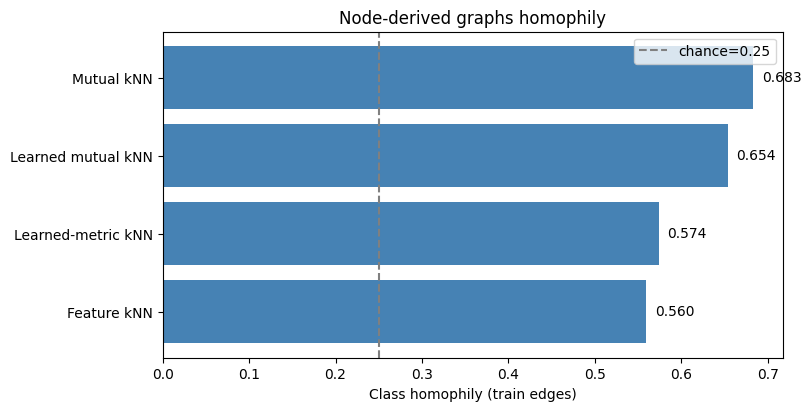

Saved ablation_g_homophily.png


In [10]:
fig,ax=plt.subplots(figsize=(8,4),constrained_layout=True)
d=homo_df.dropna(subset=['Train homophily']).sort_values('Train homophily')
ax.barh(d['Graph'],d['Train homophily'],color='steelblue')
ax.axvline(chance,ls='--',c='gray',label=f'chance={chance:.2f}')
for y_,v in enumerate(d['Train homophily']): ax.text(v+0.01,y_,f'{v:.3f}',va='center')
ax.set_xlabel('Class homophily (train edges)'); ax.set_title('Node-derived graphs homophily'); ax.legend()
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_g_homophily.png'),dpi=120,bbox_inches='tight'); plt.show()
print('Saved ablation_g_homophily.png')

## 10. Model & Training (hierarchical dual head, full-batch)

In [11]:
class HierGAT(nn.Module):
    def __init__(self,d_in,n_sc,n_cl):
        super().__init__()
        self.in_lin=nn.Linear(d_in,HIDDEN)
        self.convs=nn.ModuleList(); self.norms=nn.ModuleList()
        for _ in range(NUM_LAYERS):
            self.convs.append(GATConv(HIDDEN,HIDDEN//NUM_HEADS,heads=NUM_HEADS,edge_dim=1,
                                      add_self_loops=True,dropout=DROPOUT))
            self.norms.append(nn.LayerNorm(HIDDEN))
        self.jk=nn.Linear(HIDDEN*NUM_LAYERS,HIDDEN)
        self.head_sc=nn.Linear(HIDDEN,n_sc)
        self.head_cl=nn.Linear(HIDDEN,n_cl)
    def forward(self,x,ei,ew,drop_edge=True):
        if drop_edge and self.training and ei.numel()>0 and DROP_EDGE_P>0:
            ei,mask=dropout_edge(ei,p=DROP_EDGE_P)
            ew=ew[mask] if (ew is not None and ew.numel()>0) else ew
        h=F.relu(self.in_lin(x)); outs=[]
        ea=ew.unsqueeze(1) if (ew is not None and ew.numel()>0) else None
        for conv,norm in zip(self.convs,self.norms):
            h=conv(h,ei,edge_attr=ea) if ei.numel()>0 else conv(h,ei)
            h=F.relu(norm(h)); outs.append(h)
        h=F.relu(self.jk(torch.cat(outs,1)))
        return self.head_sc(h), self.head_cl(h)

def hier_mask_logits(logit_cl,logit_sc):
    pred_sc=logit_sc.argmax(1)
    allowed=sc_to_cl_mask_dev[pred_sc]
    return logit_cl.masked_fill(~allowed,float('-inf'))

def _train(x_np,edge_index,edge_w,seed=42,return_pred=False):
    torch.manual_seed(seed)
    X=torch.tensor(x_np,dtype=torch.float32,device=DEVICE)
    if edge_index is not None and edge_index.numel()>0:
        ei=edge_index.to(DEVICE)
        ew=edge_w.to(DEVICE) if (edge_w is not None and edge_w.numel()>0) else torch.empty(0,device=DEVICE)
    else:
        ei=torch.empty((2,0),dtype=torch.long,device=DEVICE); ew=torch.empty(0,device=DEVICE)
    ne=int(ei.shape[1])
    model=HierGAT(X.shape[1],N_SC,N_CL).to(DEVICE)
    opt=torch.optim.Adam(model.parameters(),lr=CLF_LR,weight_decay=5e-4)
    amp=(USE_AMP and DEVICE=='cuda')
    scaler=torch.cuda.amp.GradScaler(enabled=amp)
    best=-1; best_state=None; best_ep=0; patience=0
    for ep in range(CLF_EPOCHS):
        model.train(); opt.zero_grad()
        with torch.autocast(device_type='cuda',enabled=amp):
            ls,lc=model(X,ei,ew)
            loss=W_SC*F.cross_entropy(ls[train_mask_dev],y_sc_dev[train_mask_dev],weight=sc_wts)\
                +W_CL*F.cross_entropy(lc[train_mask_dev],y_cl_dev[train_mask_dev],weight=cl_wts)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        model.eval()
        with torch.no_grad():
            vs,vc=model(X,ei,ew,drop_edge=False); vcm=hier_mask_logits(vc,vs)
            vf1=f1_score(y_cl_dev[val_mask_dev].cpu(),vcm[val_mask_dev].argmax(1).cpu(),average='macro')
        if vf1>best: best=vf1; best_ep=ep; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}; patience=0
        else:
            patience+=1
            if patience>=CLF_PATIENCE: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        ts,tc=model(X,ei,ew,drop_edge=False); tcm=hier_mask_logits(tc,ts)
        yp=tcm[test_mask_dev].argmax(1).cpu().numpy(); yt=y_cl_dev[test_mask_dev].cpu().numpy()
    f1=f1_score(yt,yp,average='macro'); acc=accuracy_score(yt,yp)
    del X,ei,ew,model,opt; free()
    if return_pred: return yt,yp,best,best_ep,ne
    return {'Variant':None,'Edges':ne,'Best epoch':best_ep,'Val F1':round(best,4),
            'Test Acc':round(acc*100,2),'Test F1':round(f1,4)}

def run_variant(name,x_np,ei,ew):
    r=_train(x_np,ei,ew); r['Variant']=name
    print(f'  {name:<22} edges={r["Edges"]:>8,}  ep={r["Best epoch"]:<3}  val={r["Val F1"]:.4f}  TEST acc={r["Test Acc"]:.2f}%  F1={r["Test F1"]:.4f}')
    return r
print('Model ready.')

Model ready.


## 11. Run Node-derived Variants

In [12]:
empty_ei=torch.empty((2,0),dtype=torch.long); empty_w=torch.empty(0)
results=[]
print('Training ...')
results.append(run_variant('No graph (control)',x_spec,empty_ei,empty_w))
results.append(run_variant('Feature kNN',       x_spec,*graphs['Feature kNN']))
results.append(run_variant('Mutual kNN',        x_spec,*graphs['Mutual kNN']))
results.append(run_variant('Learned-metric kNN',x_spec,*graphs['Learned-metric kNN']))
results.append(run_variant('Learned mutual kNN',x_spec,*graphs['Learned mutual kNN']))
res_df=pd.DataFrame(results)
print('\n'+res_df.to_string(index=False)); res_df.to_csv(os.path.join(RESULTS_DIR, 'ablation_g_results.csv'),index=False)

Training ...
  No graph (control)     edges=       0  ep=52   val=0.5420  TEST acc=57.96%  F1=0.5225
  Feature kNN            edges=1,693,840  ep=96   val=0.6094  TEST acc=66.47%  F1=0.5952
  Mutual kNN             edges= 675,056  ep=89   val=0.5893  TEST acc=63.65%  F1=0.5755
  Learned-metric kNN     edges=1,693,840  ep=110  val=0.5422  TEST acc=59.48%  F1=0.5225
  Learned mutual kNN     edges= 327,724  ep=37   val=0.5305  TEST acc=57.87%  F1=0.5112

           Variant   Edges  Best epoch  Val F1  Test Acc  Test F1
No graph (control)       0          52  0.5420     57.96   0.5225
       Feature kNN 1693840          96  0.6094     66.47   0.5952
        Mutual kNN  675056          89  0.5893     63.65   0.5755
Learned-metric kNN 1693840         110  0.5422     59.48   0.5225
Learned mutual kNN  327724          37  0.5305     57.87   0.5112


## 12 MCN (Leiden communities) + MWST  ->  GNN

Same pipeline but applied to a **homophilous base graph** (learned-metric kNN) instead of MASST:

1. Build the base graph over **all nodes** (train+val+test) in the learned-metric
   embedding space (`x_emb`) 
2. **Leiden** community detection on every connected component of that all-nodes graph.
3. Per community, keep the **maximum-weight spanning tree** (MWST) as the backbone
   (the MCN).
4. Compute the same **4 community features** (log size, normalised degree,
   dist-to-centroid, singleton flag) **directly for all nodes** from this single
   transductive community assignment.
5. Train the GNN on the MCN backbone; the training loss stays masked to train nodes
   only (leakage-free transductive learning).

This isolates whether the MCN·MWST step adds anything *on top of* a good graph.

In [13]:
import igraph as ig, leidenalg
from scipy.sparse.csgraph import minimum_spanning_tree as _mst
from scipy.sparse import csr_matrix as _csr

# --- base graph over ALL nodes (learned-metric kNN, transductive) ---
print('Building transductive base graph (learned-metric kNN, all nodes) ...')
bs,bd,bw=knn_cosine(x_emb,KNN_K)
a=np.minimum(bs,bd); b=np.maximum(bs,bd); mkey=a.astype(np.int64)*np.int64(1e9)+b
_,uidx=np.unique(mkey,return_index=True)
eu,ev,ew_loc=a[uidx],b[uidx],bw[uidx]
print(f'  base undirected edges: {len(eu):,}')

# --- Leiden on connected components (all nodes -- ablation_a pipeline) ---
print('Leiden ...')
import networkx as nx
G=nx.Graph(); G.add_nodes_from(range(N_NODES))
for u,v,w in zip(eu,ev,ew_loc): G.add_edge(int(u),int(v),cosine_score=float(max(w,0)))
pos_to_comm={}; nid=0
for comp in sorted(nx.connected_components(G),key=len,reverse=True):
    cs=sorted(comp); sz=len(cs)
    if sz==1: pos_to_comm[cs[0]]=nid; nid+=1
    elif sz<MIN_LEIDEN_SIZE:
        for n in cs: pos_to_comm[n]=nid
        nid+=1
    else:
        remap={o:i for i,o in enumerate(cs)}; sg=G.subgraph(cs)
        ic=ig.Graph(n=sz,directed=False)
        ic.add_edges([(remap[u],remap[v]) for u,v in sg.edges()])
        ic.es['weight']=[sg.edges[u,v]['cosine_score'] for u,v in sg.edges()]
        part=leidenalg.find_partition(ic,leidenalg.ModularityVertexPartition,weights='weight',seed=LEIDEN_SEED)
        for li,mp in enumerate(cs): pos_to_comm[mp]=nid+int(part.membership[li])
        nid+=len(part)
n_comm=nid
print(f'  communities: {n_comm:,}')

# per-community MWST backbone (all nodes)
print('MWST backbone ...')
comm_nodes=defaultdict(list)
for mp,c in pos_to_comm.items(): comm_nodes[c].append(mp)
mst_edges=[]
for c in range(n_comm):
    mem=comm_nodes[c]
    if len(mem)<=1: continue
    li={mp:i for i,mp in enumerate(mem)}; rows=[];cols=[];wts=[]
    for u in mem:
        for v in G.neighbors(u):
            if pos_to_comm.get(v)==c and v in li:
                rows.append(li[u]);cols.append(li[v]);wts.append(G.edges[u,v]['cosine_score'])
    if not rows: continue
    mat=_csr((np.array(wts,dtype=np.float32),(rows,cols)),shape=(len(mem),len(mem)))
    neg=mat.copy(); neg.data*=-1; t=_mst(neg).tocoo(); t.data*=-1
    for r,cc,w in zip(t.row,t.col,t.data): mst_edges.append((mem[r],mem[cc],float(w)))
print(f'  MCN MWST edges: {len(mst_edges):,}')

Building transductive base graph (learned-metric kNN, all nodes) ...
  base undirected edges: 764,989
Leiden ...
  communities: 11
MWST backbone ...
  MCN MWST edges: 84,681


In [14]:
# 4 community features, computed directly for ALL nodes (transductive, no extrapolation) 
def mcn_features():
    comm_id=np.array([pos_to_comm[i] for i in range(N_NODES)])
    sizes=np.bincount(comm_id,minlength=n_comm)
    cent=np.zeros((n_comm,x_spec.shape[1]),dtype=np.float32)
    np.add.at(cent,comm_id,x_spec); cent/=np.maximum(sizes[:,None],1)
    f_log=np.log1p(sizes[comm_id]).astype(np.float32)
    deg=np.array([G.degree(i) for i in range(N_NODES)],dtype=np.float32)
    f_deg=(deg/np.maximum(sizes[comm_id]-1,1)).clip(0,1)
    f_dist=np.linalg.norm(x_spec-cent[comm_id],axis=1).astype(np.float32)
    f_sing=np.array([1.0 if G.degree(i)==0 else 0.0 for i in range(N_NODES)],dtype=np.float32)
    feats=np.stack([f_log,f_deg,f_dist,f_sing],axis=1).astype(np.float32)
    return np.concatenate([x_spec,feats],axis=1).astype(np.float32)

x_mcn=mcn_features()
# MST edges are already in global node positions -- make bidirectional
gs=np.array([u for u,v,w in mst_edges])
gd=np.array([v for u,v,w in mst_edges])
gw=np.array([w for u,v,w in mst_edges],dtype=np.float32)
ei_mcn=torch.tensor(np.stack([np.concatenate([gs,gd]),np.concatenate([gd,gs])]),dtype=torch.long)
ew_mcn=torch.tensor(np.concatenate([gw,gw]),dtype=torch.float32).clamp(min=0)
h_mcn,_=homophily(ei_mcn,y_np,tr_mask_np)
print(f'MCN feat dim={x_mcn.shape[1]}  edges={ei_mcn.shape[1]:,}  train homophily={h_mcn:.4f}')

print('Training GNN on MCN (Leiden+MWST) ...')
r_mcn=run_variant('MCN (Leiden+MWST)',x_mcn,ei_mcn,ew_mcn)
results.append(r_mcn); res_df=pd.DataFrame(results); res_df.to_csv(os.path.join(RESULTS_DIR, 'ablation_g_results.csv'),index=False)
# add MCN homophily to the table
homo_df=pd.concat([homo_df,pd.DataFrame([{'Graph':'MCN (Leiden+MWST)','Edges':int(ei_mcn.shape[1]),
        'Train homophily':round(h_mcn,4),'Lift vs chance':round(h_mcn/chance,2),'All-edge homophily':np.nan}])],ignore_index=True)
print('\n'+res_df.to_string(index=False))

MCN feat dim=344  edges=169,362  train homophily=0.5879
Training GNN on MCN (Leiden+MWST) ...
  MCN (Leiden+MWST)      edges= 169,362  ep=76   val=0.5393  TEST acc=58.90%  F1=0.5199

           Variant   Edges  Best epoch  Val F1  Test Acc  Test F1
No graph (control)       0          52  0.5420     57.96   0.5225
       Feature kNN 1693840          96  0.6094     66.47   0.5952
        Mutual kNN  675056          89  0.5893     63.65   0.5755
Learned-metric kNN 1693840         110  0.5422     59.48   0.5225
Learned mutual kNN  327724          37  0.5305     57.87   0.5112
 MCN (Leiden+MWST)  169362          76  0.5393     58.90   0.5199


## 13 Summary: homophily vs accuracy

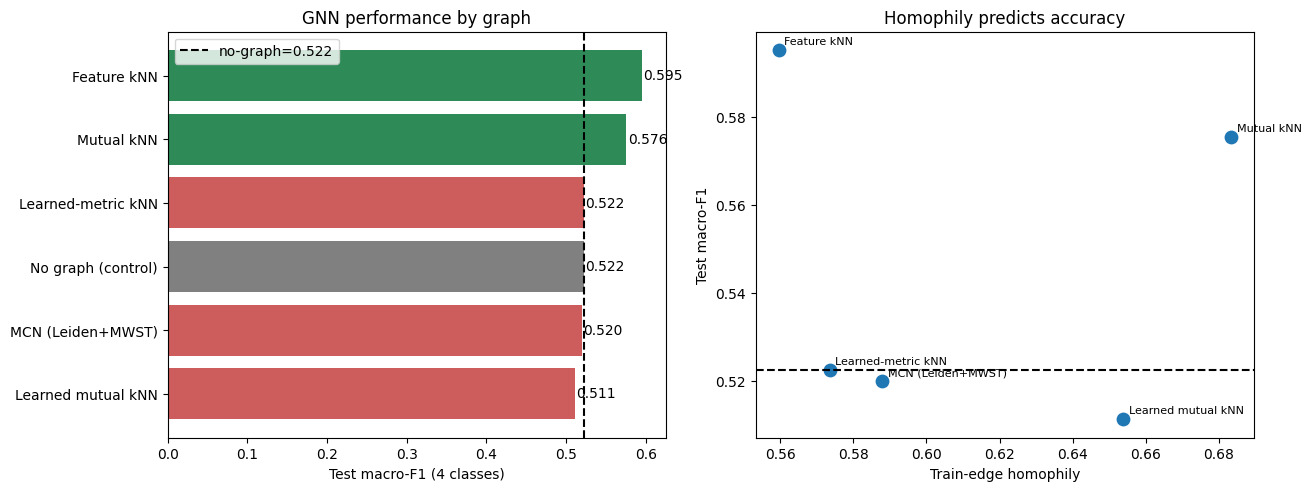

Saved ablation_g_summary.png


In [15]:
base=res_df.loc[res_df['Variant']=='No graph (control)','Test F1'].iloc[0]
fig,ax=plt.subplots(1,2,figsize=(13,4.8),constrained_layout=True)
a=ax[0]; d=res_df.sort_values('Test F1')
colors=['gray' if v=='No graph (control)' else ('seagreen' if f>base else 'indianred') for v,f in zip(d['Variant'],d['Test F1'])]
a.barh(d['Variant'],d['Test F1'],color=colors); a.axvline(base,ls='--',c='black',label=f'no-graph={base:.3f}')
for y_,v in enumerate(d['Test F1']): a.text(v+0.002,y_,f'{v:.3f}',va='center')
a.set_xlabel('Test macro-F1 (4 classes)'); a.set_title('GNN performance by graph'); a.legend()
b=ax[1]; m=res_df.merge(homo_df[['Graph','Train homophily']],left_on='Variant',right_on='Graph',how='left').dropna(subset=['Train homophily'])
b.scatter(m['Train homophily'],m['Test F1'],s=80)
for _,r in m.iterrows(): b.annotate(r['Variant'],(r['Train homophily'],r['Test F1']),fontsize=8,xytext=(4,4),textcoords='offset points')
b.axhline(base,ls='--',c='black'); b.set_xlabel('Train-edge homophily'); b.set_ylabel('Test macro-F1'); b.set_title('Homophily predicts accuracy')
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_g_summary.png'),dpi=120,bbox_inches='tight'); plt.show()
print('Saved ablation_g_summary.png')

## 14 Per-Class F1 (4 classes)

Best variant: Feature kNN
                              Class  Test support  F1 no-graph  F1 Feature kNN  Delta
                        Fatty Acyls          2785       0.5575          0.6549 0.0974
Benzene and substituted derivatives          8459       0.7175          0.7989 0.0814
   Carboxylic acids and derivatives          3564       0.4565          0.5247 0.0682
             Organooxygen compounds          2131       0.3584          0.3918 0.0334


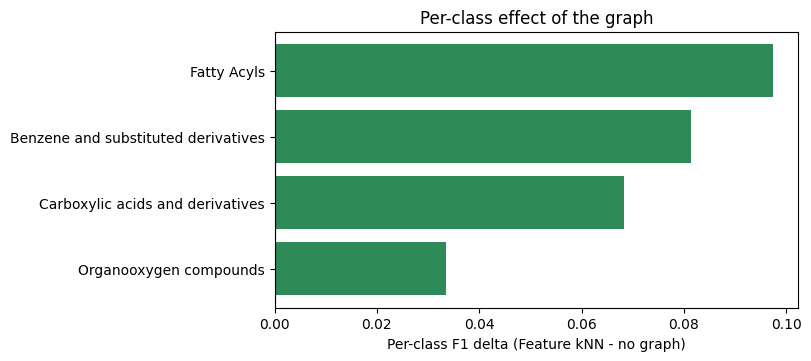

Saved ablation_g_per_class.png


In [16]:
best_name=res_df[res_df['Variant']!='No graph (control)'].sort_values('Test F1')['Variant'].iloc[-1]
if best_name=='MCN (Leiden+MWST)': bei,bew=ei_mcn,ew_mcn; bx=x_mcn
else: bei,bew=graphs[best_name]; bx=x_spec
print('Best variant:',best_name)
yt0,yp0,_,_,_=_train(x_spec,torch.empty((2,0),dtype=torch.long),torch.empty(0),return_pred=True)
ytg,ypg,_,_,_=_train(bx,bei,bew,return_pred=True)
labels=np.arange(N_CL)
pc=pd.DataFrame({'Class':le.classes_,'Test support':np.bincount(yt0,minlength=N_CL),
                 'F1 no-graph':np.round(f1_score(yt0,yp0,average=None,labels=labels),4),
                 f'F1 {best_name}':np.round(f1_score(ytg,ypg,average=None,labels=labels),4)})
pc['Delta']=np.round(pc[f'F1 {best_name}']-pc['F1 no-graph'],4)
pc=pc.sort_values('Delta',ascending=False); pc.to_csv(os.path.join(RESULTS_DIR, 'ablation_g_per_class.csv'),index=False)
print(pc.to_string(index=False))
fig,ax=plt.subplots(figsize=(8,3.5),constrained_layout=True)
ax.barh(pc['Class'],pc['Delta'],color=['seagreen' if d>0 else 'indianred' for d in pc['Delta']])
ax.axvline(0,c='black',lw=0.8); ax.invert_yaxis()
ax.set_xlabel(f'Per-class F1 delta ({best_name} - no graph)'); ax.set_title('Per-class effect of the graph')
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_g_per_class.png'),dpi=120,bbox_inches='tight'); plt.show()
print('Saved ablation_g_per_class.png')

## 15 kNN `k` Sweep (learned-metric)

  k=5   edges= 846,920 homophily=0.5801 F1=0.5206
  k=10  edges=1,693,840 homophily=0.5736 F1=0.5225
  k=15  edges=2,540,760 homophily=0.5700 F1=0.5215
  k=30  edges=5,081,520 homophily=0.5650 F1=0.5111


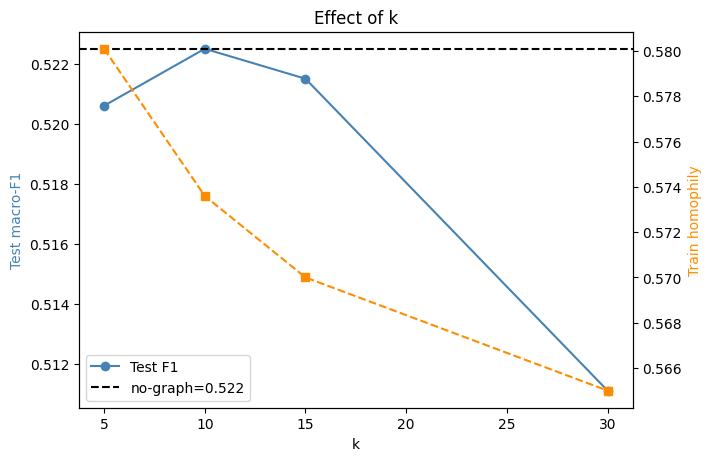


 k   Edges  Train homophily  Test F1
 5  846920           0.5801   0.5206
10 1693840           0.5736   0.5225
15 2540760           0.5700   0.5215
30 5081520           0.5650   0.5111
Saved ablation_g_ksweep.png


In [17]:
K_GRID=[5,10,15,30]; sweep=[]
for k in K_GRID:
    ks,kd,ksim=knn_cosine(x_emb,k); kei,kew=build_symmetric(ks,kd,ksim)
    h_k,_=homophily(kei,y_np,tr_mask_np); r=_train(x_spec,kei,kew)
    sweep.append({'k':k,'Edges':int(kei.shape[1]),'Train homophily':round(h_k,4),'Test F1':r['Test F1']})
    print(f'  k={k:<3} edges={kei.shape[1]:>8,} homophily={h_k:.4f} F1={r["Test F1"]:.4f}')
sweep_df=pd.DataFrame(sweep); sweep_df.to_csv(os.path.join(RESULTS_DIR, 'ablation_g_ksweep.csv'),index=False)
fig,ax=plt.subplots(figsize=(7,4.5),constrained_layout=True)
ax.plot(sweep_df['k'],sweep_df['Test F1'],'o-',color='steelblue',label='Test F1')
ax.axhline(base,ls='--',c='black',label=f'no-graph={base:.3f}')
ax.set_xlabel('k'); ax.set_ylabel('Test macro-F1',color='steelblue')
ax2=ax.twinx(); ax2.plot(sweep_df['k'],sweep_df['Train homophily'],'s--',color='darkorange',label='homophily')
ax2.set_ylabel('Train homophily',color='darkorange'); ax.set_title('Effect of k'); ax.legend(loc='lower left')
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_g_ksweep.png'),dpi=120,bbox_inches='tight'); plt.show()
print('\n'+sweep_df.to_string(index=False)); print('Saved ablation_g_ksweep.png')